# pilot - Bitcoin decentralisation

The whole project in miniature: pull 1,000 random blocks, attribute each to a
pool by its coinbase tag, compute the Nakamoto coefficient, and plot it.

Prereqs : `pip install -r requirements.txt`, and
`gcloud auth application-default login`.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery



PROJECT_ID = "project-9536b219-93fb-4fca-aac"   

client = bigquery.Client(project=PROJECT_ID)
print("BigQuery client ready, billing project:", client.project)

BigQuery client ready, billing project: project-9536b219-93fb-4fca-aac


## Step 1 - pull 1,000 random blocks

We only need the coinbase tag, which lives in `coinbase_param` on the **`blocks`**
table (~950k rows). We never touch the giant `transactions` table here, so the
scan is tiny.

In [2]:
QUERY = """
SELECT
  number    AS height,
  timestamp,
  coinbase_param
FROM `bigquery-public-data.crypto_bitcoin.blocks`
WHERE coinbase_param IS NOT NULL
ORDER BY RAND()
LIMIT 1000
"""

# DRY RUN: estimate bytes scanned without running the query
dry = client.query(QUERY, bigquery.QueryJobConfig(dry_run=True, use_query_cache=False))
gb = dry.total_bytes_processed / 1e9
print(f"This query will scan ~{gb:.4f} GB ({gb*1000:.1f} MB).  Free tier = 1000 GB/month.")
assert gb < 5, "Unexpectedly large scan — investigate before running for real."

This query will scan ~0.1317 GB (131.7 MB).  Free tier = 1000 GB/month.


In [3]:

blocks_df = client.query(QUERY).to_dataframe()
print("shape:", blocks_df.shape)
blocks_df.head()

C:\Users\Nakis\Documents\Thesis Papers\Thesis\bitcoin-decentralisation\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


shape: (1000, 3)


,height,timestamp,coinbase_param
0,365260,2015-07-14 09:54:54+00:00,03cc9205fabe6d6d7b1dcb7fed797d5057d1b2d88ec9d0...
1,952468,2026-06-05 11:08:02+00:00,0394880e194d696e656420627920416e74506f6f6c209f...
2,306175,2014-06-16 17:10:01+00:00,03ffab0404001dd24359124d696e656420627920425443...
3,476495,2017-07-19 06:59:07+00:00,034f45070435036f592f424154504f4f4c2f4e59412ffa...
4,130228,2011-06-12 07:42:03+00:00,042f931d1a02fb05


## Step 2 - decode the coinbase tag

`coinbase_param` is a hex string. The pool tag is human-readable text buried
among non-printable bytes (block height, extranonce). We decode to best-effort
ASCII, turning unreadable bytes into `.` so the tag stands out.

In [4]:
def coinbase_to_ascii(hex_str):
    """Hex coinbase_param -> best-effort printable ASCII (non-printable -> '.')."""
    if not hex_str:
        return ""
    try:
        raw = bytes.fromhex(hex_str)
    except (ValueError, TypeError):
        return str(hex_str)
    return "".join(chr(b) if 32 <= b < 127 else "." for b in raw)

blocks_df["coinbase_ascii"] = blocks_df["coinbase_param"].apply(coinbase_to_ascii)

# eyeball 25 of them
for s in blocks_df["coinbase_ascii"].head(25):
    print(s)

......mm{....y}PW..........b....]...?s..................................96072.......................
.....Mined by AntPool ..G.*..?..mm..1sX.D...s.....(f..e.+7.%`.p...............1?......
........CY.Mined by BTC Guild,..mm.@33#....=.e.Dk)N......G.Y.?8..$..........PqQ...6
.OE..5.oY/BATPOOL/NYA/..mm.."XQ..._...j...P.....r%V..`...X..............m.....
./......
.B....mm....D.4T...s<....V....?...3...V.........$i...S+.`....%/slush/
.......(.X..h.,.7..X..<s./Bitfury/SEGWIT/
.#~....de/Foundry USA Pool #dropgold/Hy..........
.K.../P2SH/.v.CR.6.....B..R,..mm.&5k.+..7.Gx{..,..C.....}(.$)a3V........
.6...................mm.Vm=%....A.d....<;E..O....^W5Y..................Mined by grkjltyhd
.....Mined by AntPool .... .NW.........
....Mined By ASICMiner....
..r...;......Z|..%..../BTCC/ Support /NYA/..........................................................
._......Zd/BTC.COM/..mmwx......!....9V._HV.....".``..8.........<.p...o.....
.SY....
psj........~.R,..mm..........hi from poolserverj.....
...../P2S

## Step 3 - match against 5 hand-typed pools

A deliberately crude tag matcher over five well-known pools. **This crudeness is
the point of your whole dissertation** - which reference list, which matching
rule, and how you treat everything that doesn't match (D2, and the heuristics
H1–H5).

In [5]:
POOL_TAGS = {
    "F2Pool":    ["f2pool"],
    "AntPool":   ["antpool"],
    "ViaBTC":    ["viabtc"],
    "SlushPool": ["slush"],     # also catches the older "/slush/" tag
    "BTC.com":   ["btc.com", "btccom"],
}

def attribute_by_tag(ascii_script):
    s = ascii_script.lower()
    for pool, needles in POOL_TAGS.items():
        if any(n in s for n in needles):
            return pool
    return "unknown"

blocks_df["pool"] = blocks_df["coinbase_ascii"].apply(attribute_by_tag)

counts = blocks_df["pool"].value_counts()
print(counts.to_string())
unknown_share = counts.get("unknown", 0) / len(blocks_df)
print(f"\nunknown: {unknown_share:.1%} of blocks")

pool
unknown      698
AntPool      111
ViaBTC        55
SlushPool     49
BTC.com       45
F2Pool        42

unknown: 69.8% of blocks


## Step 4 - Nakamoto coefficient (and the choice that changes it)

The Nakamoto coefficient = the smallest number of entities jointly controlling
>50% of blocks. We compute it **two ways**: counting `unknown` as a single
entity, and excluding it. These are two of your D3 variants (U1 vs U2). 

In [6]:
def nakamoto_coefficient(entity_counts):
    shares = pd.Series(entity_counts).sort_values(ascending=False)
    total = shares.sum()
    if total == 0:
        return 0
    cum = 0
    for i, (_e, n) in enumerate(shares.items(), start=1):
        cum += n
        if cum / total > 0.5:
            return i
    return len(shares)

nak_incl  = nakamoto_coefficient(counts)
nak_known = nakamoto_coefficient(counts.drop("unknown", errors="ignore"))

print(f"Nakamoto, unknown as one entity (U1): {nak_incl}")
print(f"Nakamoto, unknown excluded      (U2): {nak_known}")

Nakamoto, unknown as one entity (U1): 1
Nakamoto, unknown excluded      (U2): 2


## Step 5 -plot

Sorted block share per entity (bars) with the running cumulative share (line).
Where the cumulative line crosses the dashed 50% mark *is* the Nakamoto
coefficient, you can read it straight off the x-axis.

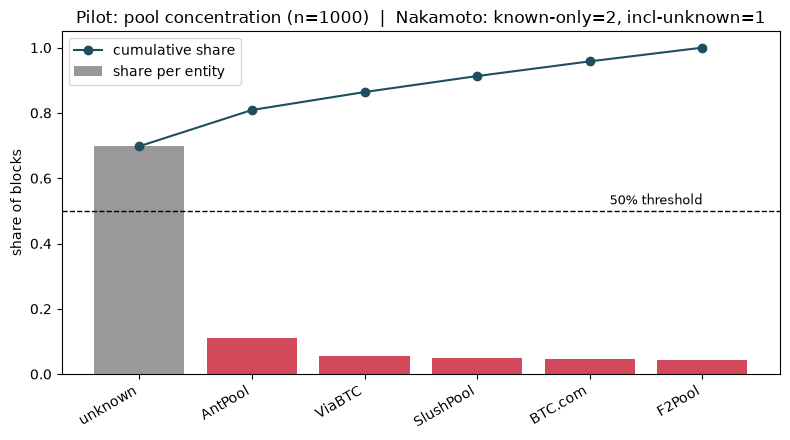

In [7]:
import os

shares = (counts / counts.sum()).sort_values(ascending=False)
cum = shares.cumsum()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#999999" if e == "unknown" else "#d1495b" for e in shares.index]
ax.bar(range(len(shares)), shares.values, color=colors, label="share per entity")
ax.plot(range(len(shares)), cum.values, "o-", color="#1f4e5f", label="cumulative share")
ax.axhline(0.5, ls="--", color="black", lw=1)
ax.text(len(shares) - 1, 0.52, "50% threshold", ha="right", fontsize=9)
ax.set_xticks(range(len(shares)))
ax.set_xticklabels(shares.index, rotation=30, ha="right")
ax.set_ylabel("share of blocks")
ax.set_title(f"Pilot: pool concentration (n={len(blocks_df)})  |  "
             f"Nakamoto: known-only={nak_known}, incl-unknown={nak_incl}")
ax.legend()
fig.tight_layout()

os.makedirs("../figures", exist_ok=True)   # assumes you run this from notebooks/
fig.savefig("../figures/pilot_shares.png", dpi=120, bbox_inches="tight")
plt.show()